# Iris 데이터셋 로지스틱 회귀 분류 실습 - PyTorch

이 노트북은 Iris 데이터셋을 사용하여 **로지스틱 회귀(Logistic Regression)** 알고리즘으로 붓꽃 품종을 분류하는 전체 머신러닝 작업 흐름을 구현합니다.

## 머신러닝 작업 순서

1. 라이브러리 불러오기
2. 실행 장치 설정
3. 데이터셋 불러오기
4. 입력 데이터와 정답 라벨 분리
5. 학습 데이터 / 테스트 데이터 분리
6. 데이터 표준화
7. PyTorch Tensor 변환
8. 로지스틱 회귀 모델 클래스 정의
9. 손실 함수와 최적화 알고리즘 설정
10. 모델 학습
11. 모델 평가
12. 새 데이터 예측
13. 학습 손실 시각화

> Iris 데이터셋은 3개 품종을 분류하는 다중 클래스 분류 문제입니다.  
> PyTorch에서는 다중 클래스 로지스틱 회귀를 `nn.Linear` + `CrossEntropyLoss` 조합으로 구현합니다.


In [1]:
# ============================================================
# 1. 기본 라이브러리 불러오기
# ============================================================

# PyTorch 핵심 라이브러리입니다.
# Tensor 연산, GPU 연산, 모델 학습에 사용합니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# sklearn.datasets는 실습용 내장 데이터셋을 제공합니다.
# load_iris()는 붓꽃 분류 실습용 Iris 데이터셋을 불러옵니다.
from sklearn.datasets import load_iris

# train_test_split은 전체 데이터를 학습용과 테스트용으로 나누는 함수입니다.
from sklearn.model_selection import train_test_split

# StandardScaler는 입력 데이터의 평균을 0, 표준편차를 1로 맞추는 표준화 도구입니다.
from sklearn.preprocessing import StandardScaler

# accuracy_score는 분류 정확도를 계산합니다.
# classification_report는 precision, recall, f1-score를 출력합니다.
# confusion_matrix는 실제값과 예측값의 교차표를 만듭니다.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# pandas는 표 형태의 데이터를 다루기 위해 사용합니다.
import pandas as pd

# numpy는 배열 연산을 위해 사용합니다.
import numpy as np

# matplotlib은 그래프 시각화를 위해 사용합니다.
import matplotlib.pyplot as plt

print("라이브러리 불러오기 완료")


라이브러리 불러오기 완료


In [2]:
# ============================================================
# 2. 실행 장치 설정
# ============================================================

# GPU 사용이 가능하면 cuda를 사용하고, 그렇지 않으면 cpu를 사용합니다.
# Google Colab에서는 런타임 유형을 GPU로 변경하면 cuda 사용이 가능합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 사용 중인 장치를 출력합니다.
print("사용 장치:", device)


사용 장치: cpu


In [3]:
# ============================================================
# 3. Iris 데이터셋 불러오기
# ============================================================

# load_iris() 함수로 Iris 데이터셋을 불러옵니다.
# Iris 데이터셋은 붓꽃의 꽃받침, 꽃잎 길이/너비 정보를 이용하여 품종을 분류하는 데이터셋입니다.
iris = load_iris()

# iris.data에는 입력 특성 4개가 들어 있습니다.
# 특성: sepal length, sepal width, petal length, petal width
X = iris.data

# iris.target에는 정답 클래스 번호가 들어 있습니다.
# 0: setosa, 1: versicolor, 2: virginica
y = iris.target

# 품종 이름을 저장합니다.
target_names = iris.target_names

# 특성 이름을 저장합니다.
feature_names = iris.feature_names

# 데이터를 DataFrame으로 변환하여 구조를 보기 쉽게 만듭니다.
df = pd.DataFrame(X, columns=feature_names)

# 정답 라벨 번호 컬럼을 추가합니다.
df["target"] = y

# 정답 라벨 이름 컬럼을 추가합니다.
df["species"] = [target_names[label] for label in y]

# 데이터 앞부분 5개 행을 확인합니다.
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# ============================================================
# 4. 데이터 기본 정보 확인
# ============================================================

# 데이터 크기를 출력합니다.
# X는 입력 데이터, y는 정답 라벨입니다.
print("입력 데이터 X 크기:", X.shape)
print("정답 라벨 y 크기:", y.shape)

# 특성 이름을 출력합니다.
print("특성 이름:", feature_names)

# 클래스 이름을 출력합니다.
print("클래스 이름:", target_names)

# 클래스별 데이터 개수를 확인합니다.
print("클래스별 개수:")
print(df["species"].value_counts())

# 수치형 데이터의 통계 정보를 확인합니다.
df.describe()


입력 데이터 X 크기: (150, 4)
정답 라벨 y 크기: (150,)
특성 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
클래스 이름: ['setosa' 'versicolor' 'virginica']
클래스별 개수:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# ============================================================
# 5. 학습 데이터와 테스트 데이터 분리
# ============================================================

# train_test_split()으로 데이터를 학습용과 테스트용으로 분리합니다.
# test_size=0.2는 전체 데이터의 20%를 테스트 데이터로 사용한다는 의미입니다.
# random_state=42는 실행할 때마다 같은 결과가 나오도록 난수 시드를 고정합니다.
# stratify=y는 각 클래스 비율이 학습/테스트 데이터에 비슷하게 유지되도록 합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 분리된 데이터 크기를 확인합니다.
print("X_train 크기:", X_train.shape)
print("X_test 크기:", X_test.shape)
print("y_train 크기:", y_train.shape)
print("y_test 크기:", y_test.shape)


X_train 크기: (120, 4)
X_test 크기: (30, 4)
y_train 크기: (120,)
y_test 크기: (30,)


In [6]:
# ============================================================
# 6. 입력 데이터 표준화
# ============================================================

# 로지스틱 회귀는 입력 특성의 스케일 차이에 영향을 받을 수 있습니다.
# 따라서 평균 0, 표준편차 1이 되도록 표준화합니다.
scaler = StandardScaler()

# 학습 데이터 기준으로 평균과 표준편차를 계산하고 변환합니다.
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터는 학습 데이터에서 계산한 평균과 표준편차를 그대로 사용하여 변환합니다.
# 테스트 데이터에 fit_transform을 사용하면 데이터 누수가 발생할 수 있습니다.
X_test_scaled = scaler.transform(X_test)

# 표준화 결과 일부를 확인합니다.
print("표준화 전 첫 번째 학습 데이터:", X_train[0])
print("표준화 후 첫 번째 학습 데이터:", X_train_scaled[0])


표준화 전 첫 번째 학습 데이터: [4.4 2.9 1.4 0.2]
표준화 후 첫 번째 학습 데이터: [-1.72156775 -0.33210111 -1.34572231 -1.32327558]


In [7]:
# ============================================================
# 7. NumPy 배열을 PyTorch Tensor로 변환
# ============================================================

# 입력 데이터는 실수형 Tensor로 변환합니다.
# dtype=torch.float32는 PyTorch 모델 학습에서 가장 일반적으로 사용하는 실수 자료형입니다.
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# 정답 라벨은 정수형 Tensor로 변환합니다.
# CrossEntropyLoss는 정답 라벨이 0, 1, 2 같은 정수 클래스 번호인 LongTensor여야 합니다.
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# Tensor 크기를 확인합니다.
print("X_train_tensor:", X_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)


X_train_tensor: torch.Size([120, 4])
X_test_tensor: torch.Size([30, 4])
y_train_tensor: torch.Size([120])
y_test_tensor: torch.Size([30])


In [8]:
# ============================================================
# 8. 로지스틱 회귀 모델 클래스 정의
# ============================================================

class LogisticRegressionClassifier(nn.Module):
    # Iris 다중 클래스 분류용 로지스틱 회귀 모델 클래스입니다.
    # 로지스틱 회귀는 이름에 '회귀'가 들어가지만 실제로는 분류 문제에 사용하는 알고리즘입니다.
    # Iris 데이터셋은 클래스가 3개이므로 출력 노드는 3개입니다.
    # CrossEntropyLoss는 내부적으로 Softmax를 포함하므로 forward()에서는 Softmax를 적용하지 않습니다.

    def __init__(self, input_dim, output_dim):
        # 부모 클래스 nn.Module의 초기화 메서드를 실행합니다.
        super().__init__()

        # 선형 계층을 정의합니다.
        # input_dim: 입력 특성 개수입니다. Iris 데이터셋은 특성이 4개입니다.
        # output_dim: 출력 클래스 개수입니다. Iris 품종은 3개입니다.
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        # 입력 x를 선형 계층에 통과시켜 각 클래스에 대한 점수(logit)를 계산합니다.
        # logit은 Softmax 적용 전의 원시 점수입니다.
        logits = self.linear(x)

        # CrossEntropyLoss가 내부에서 Softmax를 처리하므로 logits를 그대로 반환합니다.
        return logits


# 입력 특성 개수는 X_train의 컬럼 수입니다.
input_dim = X_train_tensor.shape[1]

# 출력 클래스 개수는 Iris 품종 개수입니다.
output_dim = len(target_names)

# 모델 객체를 생성하고 GPU 또는 CPU로 이동합니다.
model = LogisticRegressionClassifier(input_dim=input_dim, output_dim=output_dim).to(device)

# 모델 구조를 출력합니다.
print(model)


LogisticRegressionClassifier(
  (linear): Linear(in_features=4, out_features=3, bias=True)
)


In [10]:
# ============================================================
# 9. 손실 함수와 최적화 알고리즘 설정
# ============================================================

# CrossEntropyLoss는 다중 클래스 분류에서 사용하는 대표적인 손실 함수입니다.
# 모델 출력값은 [데이터 개수, 클래스 개수] 형태의 logits여야 합니다.
# 정답값은 [데이터 개수] 형태의 정수 클래스 번호여야 합니다.
criterion = nn.CrossEntropyLoss()

# Adam은 학습률을 적응적으로 조절하는 최적화 알고리즘입니다.
# lr은 learning rate, 즉 학습률입니다.
optimizer = optim.Adam(model.parameters(), lr=0.05)

# 학습 반복 횟수를 설정합니다.
epochs = 500

# 학습 과정의 손실값을 저장할 리스트입니다.
loss_history = []

print("손실 함수와 최적화 알고리즘 설정 완료")


손실 함수와 최적화 알고리즘 설정 완료


In [11]:
# ============================================================
# 10. 모델 학습
# ============================================================

for epoch in range(epochs):
    # 모델을 학습 모드로 설정합니다.
    model.train()

    # 이전 epoch에서 계산된 기울기를 초기화합니다.
    # PyTorch는 기본적으로 기울기를 누적하므로 매 반복마다 초기화해야 합니다.
    optimizer.zero_grad()

    # 학습 데이터를 모델에 입력하여 예측 점수 logits를 계산합니다.
    outputs = model(X_train_tensor)

    # 예측값 outputs와 실제 정답 y_train_tensor 사이의 손실을 계산합니다.
    loss = criterion(outputs, y_train_tensor)

    # 역전파를 수행하여 각 파라미터의 기울기를 계산합니다.
    loss.backward()

    # 계산된 기울기를 이용하여 모델 파라미터를 업데이트합니다.
    optimizer.step()

    # 현재 손실값을 리스트에 저장합니다.
    loss_history.append(loss.item())

    # 50번마다 학습 상태를 출력합니다.
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")


Epoch [50/500], Loss: 0.201443
Epoch [100/500], Loss: 0.133326
Epoch [150/500], Loss: 0.103983
Epoch [200/500], Loss: 0.087668
Epoch [250/500], Loss: 0.077349
Epoch [300/500], Loss: 0.070268
Epoch [350/500], Loss: 0.065134
Epoch [400/500], Loss: 0.061258
Epoch [450/500], Loss: 0.058241
Epoch [500/500], Loss: 0.055834


In [13]:
# ============================================================
# 11. 테스트 데이터로 모델 평가
# ============================================================

# 모델을 평가 모드로 변경합니다.
model.eval()

# 평가 단계에서는 기울기 계산이 필요하지 않습니다.
# torch.no_grad()를 사용하면 메모리 사용량이 줄고 계산이 빨라집니다.
with torch.no_grad():
    # 테스트 데이터를 모델에 입력하여 클래스별 점수를 계산합니다.
    test_outputs = model(X_test_tensor)

    # torch.max(test_outputs, 1)은 각 행에서 가장 큰 값과 그 인덱스를 반환합니다.
    # 여기서 인덱스가 예측 클래스 번호입니다.
    _, test_predicted = torch.max(test_outputs, dim=1)

# Tensor를 CPU로 이동한 뒤 NumPy 배열로 변환합니다.
y_pred = test_predicted.cpu().numpy()

# 실제 정답도 NumPy 배열로 준비합니다.
y_true = y_test

# 정확도를 계산합니다.
accuracy = accuracy_score(y_true, y_pred)

# 정확도를 출력합니다.
print("테스트 정확도:", accuracy)

# 실제 라벨 번호와 예측 라벨 번호를 품종 이름으로 변환합니다.
y_true_names = target_names[y_true]
y_pred_names = target_names[y_pred]

# 분류 성능 리포트를 출력합니다.
print("분류 리포트:")
print(classification_report(y_true_names, y_pred_names))

# 혼동 행렬을 출력합니다.
print("혼동 행렬:")
print(confusion_matrix(y_true_names, y_pred_names))


테스트 정확도: 1.0
분류 리포트:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

혼동 행렬:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [14]:
# ============================================================
# 12. 예측 결과를 표로 확인
# ============================================================

# 테스트 데이터의 원본 입력값을 DataFrame으로 변환합니다.
result_df = pd.DataFrame(X_test, columns=feature_names)

# 실제 품종 이름을 추가합니다.
result_df["actual"] = y_true_names

# 예측 품종 이름을 추가합니다.
result_df["predicted"] = y_pred_names

# 실제값과 예측값이 같은지 여부를 추가합니다.
result_df["correct"] = result_df["actual"] == result_df["predicted"]

# 결과 앞부분을 확인합니다.
result_df.head(10)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual,predicted,correct
0,4.4,3.0,1.3,0.2,setosa,setosa,True
1,6.1,3.0,4.9,1.8,virginica,virginica,True
2,4.9,2.4,3.3,1.0,versicolor,versicolor,True
3,5.0,2.3,3.3,1.0,versicolor,versicolor,True
4,4.4,3.2,1.3,0.2,setosa,setosa,True
5,6.3,3.3,4.7,1.6,versicolor,versicolor,True
6,4.6,3.6,1.0,0.2,setosa,setosa,True
7,5.4,3.4,1.7,0.2,setosa,setosa,True
8,6.5,3.0,5.2,2.0,virginica,virginica,True
9,5.4,3.0,4.5,1.5,versicolor,versicolor,True


In [15]:
# ============================================================
# 13. 새 데이터 예측 함수 만들기
# ============================================================

def predict_iris_species(model, scaler, new_data):
    # 새 Iris 데이터를 입력받아 품종을 예측하는 함수입니다.
    # model: 학습된 PyTorch 로지스틱 회귀 모델입니다.
    # scaler: 학습 데이터 기준으로 fit된 StandardScaler 객체입니다.
    # new_data: [sepal length, sepal width, petal length, petal width] 순서의 새 데이터입니다.

    # 입력 데이터를 NumPy 배열로 변환합니다.
    # reshape(1, -1)은 데이터 1개, 특성 여러 개 형태로 바꿉니다.
    new_data_np = np.array(new_data).reshape(1, -1)

    # 학습 때 사용한 scaler로 동일하게 표준화합니다.
    new_data_scaled = scaler.transform(new_data_np)

    # 표준화된 데이터를 PyTorch Tensor로 변환하고 장치로 이동합니다.
    new_data_tensor = torch.tensor(new_data_scaled, dtype=torch.float32).to(device)

    # 모델을 평가 모드로 설정합니다.
    model.eval()

    # 예측 과정에서는 기울기 계산을 하지 않습니다.
    with torch.no_grad():
        # 클래스별 점수 계산
        output = model(new_data_tensor)

        # 가장 높은 점수를 가진 클래스 번호 선택
        _, predicted_class = torch.max(output, dim=1)

    # 예측 클래스 번호를 CPU의 NumPy 값으로 변환합니다.
    predicted_index = predicted_class.cpu().numpy()[0]

    # 클래스 번호를 품종 이름으로 변환합니다.
    predicted_name = target_names[predicted_index]

    # 예측된 품종 이름을 반환합니다.
    return predicted_name


# 예측할 새 데이터입니다.
# 순서: sepal length, sepal width, petal length, petal width
sample_data = [5.1, 3.5, 1.4, 0.2]

# 새 데이터 예측을 실행합니다.
predicted_species = predict_iris_species(model, scaler, sample_data)

# 예측 결과를 출력합니다.
print("입력 데이터:", sample_data)
print("예측 품종:", predicted_species)


입력 데이터: [5.1, 3.5, 1.4, 0.2]
예측 품종: setosa


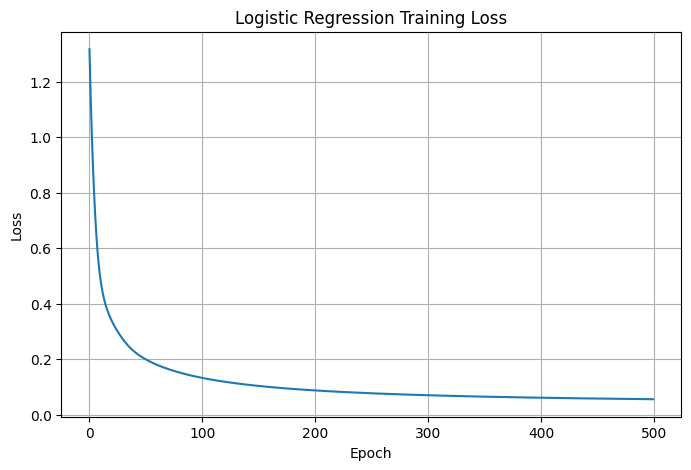

In [16]:
# ============================================================
# 14. 학습 손실 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# epoch별 손실값을 선 그래프로 표시합니다.
plt.plot(loss_history)

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Loss")

# 그래프 제목을 설정합니다.
plt.title("Logistic Regression Training Loss")

# 격자를 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


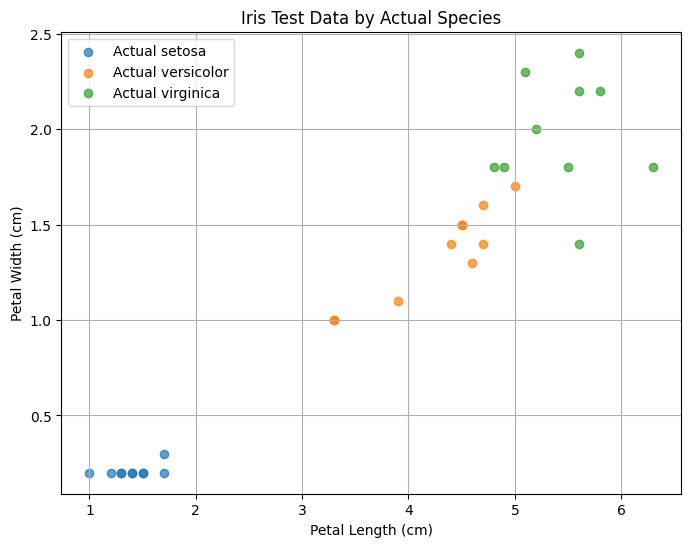

In [17]:
# ============================================================
# 15. 테스트 데이터 시각화
# ============================================================

# 결과 확인을 쉽게 하기 위해 꽃잎 길이와 꽃잎 너비만 사용하여 산점도를 그립니다.
# 실제 모델은 4개 특성을 모두 사용했지만, 시각화는 2차원으로 표현하기 위해 2개 특성만 사용합니다.
plt.figure(figsize=(8, 6))

# 실제 품종별로 색을 나누어 산점도를 그립니다.
for species_name in target_names:
    # 해당 품종 데이터만 선택합니다.
    subset = result_df[result_df["actual"] == species_name]

    # petal length와 petal width를 기준으로 산점도를 그립니다.
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=f"Actual {species_name}",
        alpha=0.7
    )

# x축 이름을 설정합니다.
plt.xlabel("Petal Length (cm)")

# y축 이름을 설정합니다.
plt.ylabel("Petal Width (cm)")

# 그래프 제목을 설정합니다.
plt.title("Iris Test Data by Actual Species")

# 범례를 표시합니다.
plt.legend()

# 격자를 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()
